In [1]:
import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rc('xtick', labelsize=18) 
matplotlib.rc('ytick', labelsize=18) 
matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)


In [ ]:
# --- jaxoplanet-backed MULTI-planet simulator (R_sun -> AU -> arcsec -> mas) ---
import jax
import jax.numpy as jnp
import jax.random as jr
from jaxoplanet.orbits.keplerian import Central, System


jax.config.update("jax_enable_x64", True)

def simulate_gaia_astrometry_multi(
    t, psi,
    planets,
    Mstar, Rstar, parallax,              # Mstar in Msun, Rstar in Rsun, parallax in mas
    mu_alpha, mu_delta,           # mas/yr
    parallax_factor, sigma_UEVA,  # parallax_factor dimensionless, sigma in mas
    x0_true=0.0, y0_true=0.0,     # mas
    seed=45,
    alpha0=0.0, delta0=0.0,       # mas
):
    import math

    # t assumed in years here
    t = jnp.asarray(t)
    psi = jnp.asarray(psi)
    t_days = jnp.asarray(t * 365.25)

    star = Central(mass=jnp.asarray(Mstar), radius = jnp.asarray(Rstar))
    sys = System(star)

    for p in planets:
        a_au = float(p["a"])

        if "Mp_sun" in p:
            mp_sun = float(p["Mp_sun"])
        else:
            mp_sun = float(p.get("Mp", 0.0)) * MJUP_TO_MSUN

        if "P" in p and p["P"] is not None:
            P_year = float(p["P"])
        else:
            P_year = math.sqrt(a_au**3 / (float(Mstar) + mp_sun))

        P_days = P_year * 365.25
        n = 2.0 * math.pi / P_days
        t_peri_days = -float(p["M0"]) / n

        sys = sys.add_body(
            period=jnp.asarray(P_days),
            eccentricity=jnp.asarray(float(p["e"])),
            inclination=jnp.asarray(float(p["i"])),
            omega_peri=jnp.asarray(float(p["omega"])),
            asc_node=jnp.asarray(float(p["Omega"])),
            time_peri=jnp.asarray(t_peri_days),
            mass=jnp.asarray(mp_sun),
        )

    # define some helpful variables
    sin_psi = jnp.sin(psi)
    cos_psi = jnp.cos(psi)

    x_sum = 0.0
    y_sum = 0.0
    for b in sys.bodies:
        x_rsun, y_rsun, _ = b.central_position(t_days)
        x_sum = x_sum + x_rsun
        y_sum = y_sum + y_rsun

    # convert from R_sun to mas and add any input offset
    # R_sun -> AU -> mas assuming parallax in mas
    RSUN_TO_AU   = 0.00465047 
    x_reflex = jnp.asarray(x_sum) * RSUN_TO_AU * parallax + x0_true
    y_reflex = jnp.asarray(y_sum) * RSUN_TO_AU * parallax + y0_true
    
    al_reflex = x_reflex * cos_psi + y_reflex * sin_psi


    
    # 5-parameter astrometry contribution (all in mas)
    # Follows the Gaia LPC convention (Lindegren & Bastian,
    # GAIA-C3-TN-LU-LL-061-08, Eqs. 4 & 6):
    #   w = a*sin theta + d*cos theta   where a ~= Deltaalpha*, d ~= Deltadelta
    al_astro = (
        sin_psi * alpha0
        + cos_psi * delta0
        + sin_psi * mu_alpha * t
        + cos_psi * mu_delta * t
        + parallax * parallax_factor
    )

    '''
    print("parallax [mas]:", parallax)
    print("alpha0 [mas]:", alpha0)
    print("delta0 [mas]:", delta0)
    print("mu_alpha [mas/yr]:", mu_alpha)
    print("mu_delta [mas/yr]:", mu_delta)

    print("parallax term range [mas]:",
        jnp.min(parallax * parallax_factor),
        jnp.max(parallax * parallax_factor))

    print("PM alpha term range [mas]:",
        jnp.min(jnp.sin(psi) * mu_alpha * t),
        jnp.max(jnp.sin(psi) * mu_alpha * t))

    print("PM delta term range [mas]:",
        jnp.min(jnp.cos(psi) * mu_delta * t),
        jnp.max(jnp.cos(psi) * mu_delta * t))

    print("offset term range [mas]:",
        jnp.min(jnp.sin(psi) * alpha0 + jnp.cos(psi) * delta0),
        jnp.max(jnp.sin(psi) * alpha0 + jnp.cos(psi) * delta0))

    print("reflex range [mas]:",
        jnp.min(al_reflex),
        jnp.max(al_reflex))
    '''

    pm_term = jnp.sin(psi) * mu_alpha * t + jnp.cos(psi) * mu_delta * t
    plx_term = parallax * parallax_factor

    '''
    plt.figure()
    plt.plot(t, pm_term, label="proper motion term")
    plt.plot(t, plx_term, label="parallax term")
    plt.plot(t, al_reflex, label="reflex term")
    plt.plot(t, al_astro, label="al_astro")
    plt.legend()
    '''
    
    al_true = al_astro + al_reflex

    key = jr.key(seed)
    sigma_true = jr.normal(key, shape=jnp.shape(t)) * sigma_UEVA #mas
    al_obs = al_true + sigma_true

    return dict(
        t=t,
        psi=psi,
        al_obs=al_obs,      # mas
        al_true=al_true,    # mas
        al_astro=al_astro,  # mas
        al_reflex=al_reflex,# mas
        sigma_true=sigma_true,  # mas
        truth={"planets": planets},
    )


def make_noise(
    astrometric_n_good_obs_al_dr3,
    astrometric_matched_transits_dr3,
    gaia_n_dof,
    sigma_calib,
    sigma_AL,
    sigma_att,
    t,
    seed=45,
):
    """
    Compute Gaia-like noise terms with shared 10% stochastic variation.

    Returns
    -------
    sigma_UEVA : ndarray
    sigma_reported : ndarray
    """


    # --------------------------------------------------
    # Core quantities
    # --------------------------------------------------
    N = astrometric_n_good_obs_al_dr3
    N_FoV = astrometric_matched_transits_dr3

    if N_FoV == 0:
        raise ValueError("N_FoV cannot be zero")

    N_AL_ave = N / N_FoV

    if (N - gaia_n_dof) == 0:
        raise ValueError("N - gaia_n_dof cannot be zero")

    # --------------------------------------------------
    # μ_UEVA_single
    # --------------------------------------------------
    mu_UEVA_single = (
        (N_AL_ave / (N - gaia_n_dof))
        * ((N_FoV - gaia_n_dof) * sigma_calib**2 + N_FoV * sigma_AL**2)
    )

    # --------------------------------------------------
    # σ_UEVA_single
    # --------------------------------------------------
    sigma_UEVA_single = jnp.sqrt(mu_UEVA_single / N_AL_ave)

    # --------------------------------------------------
    # σ_reported base
    # --------------------------------------------------
    sigma_reported_base = jnp.sqrt(sigma_att**2 + sigma_AL**2)

    # --------------------------------------------------
    # Shared 10% stochastic variation
    # --------------------------------------------------
    
    key = jr.key(seed)
    noise_factor = 1.0 + 0.1 * jr.normal(key, shape=jnp.shape(t))

    sigma_UEVA = sigma_UEVA_single * noise_factor
    sigma_reported = sigma_reported_base * noise_factor

    return sigma_UEVA, sigma_reported

def make_ra_dec_observations(data):
    """
    Construct x_obs, y_obs that are perfectly consistent with the existing
    along-scan observations (al_obs) and the true AL model (al_true),
    and compute per-epoch RA/Dec uncertainties projected from AL sigma.

    This function REQUIRES data["al_obs"] and data["al_true"].
    It will raise a KeyError if they are missing.

    Notes
    -----
    Ensures that:
        x_obs*cos(psi) + y_obs*sin(psi) == al_obs
    exactly for every epoch.
    """

    # --- Require AL data ---
    if "al_obs" not in data or "al_true" not in data:
        raise KeyError(
            "make_ra_dec_observations requires data['al_obs'] and data['al_true']. "
            "These must be produced by simulate_gaia_astrometry_multi."
        )

    # --- Build x_obs, y_obs only if not already present ---
    if ("x_obs" not in data) or ("y_obs" not in data):
        eps = data["al_obs"] - data["al_true"]    # actual AL noise
        c, s = jnp.cos(data["psi"]), jnp.sin(data["psi"])

        x_obs = data["x_true"] + eps * c
        y_obs = data["y_true"] + eps * s

        data = dict(data, x_obs=x_obs, y_obs=y_obs)

    # --- Marginal RA/Dec uncertainties (for plotting only) ---
    sigma_ra  = data["sigma"] * jnp.abs(jnp.cos(data["psi"]))
    sigma_dec = data["sigma"] * jnp.abs(jnp.sin(data["psi"]))

    return data, sigma_ra, sigma_dec





In [11]:
import numpy as np
import pandas as pd


def prepare_and_simulate_gaia_astrometry(
    gaia_source_id,
    sample_scanlaw_dr4_df,
    sample_sources_df,
    planets,
    gaia_n_dof=None,
    seed=45,
    alpha0=0.0,
    delta0=0.0,
):
    """
    Prepare inputs from sample_sources_df and sample_scanlaw_dr4_df, then run
    simulate_gaia_astrometry_multi for one source.

    Parameters
    ----------
    gaia_source_id : int or str
        Gaia source identifier to select.
    sample_scanlaw_dr4_df : pd.DataFrame
        Scanlaw dataframe with one row per Gaia observation epoch.
    sample_sources_df : pd.DataFrame
        Source-level dataframe with astrometric and noise metadata.
    planets : list of dict
        List of companion dictionaries expected by simulate_gaia_astrometry_multi.
    gaia_n_dof : float, optional
        Degrees of freedom to use in make_noise. If None, inferred from
        astrometric_params_solved_dr3 when possible, otherwise defaults to 5.
    seed : int
        RNG seed passed to the simulator and noise generator.
    alpha0, delta0 : float
        Optional astrometric offsets in mas.

    Returns
    -------
    result : dict
        Output of simulate_gaia_astrometry_multi plus some bookkeeping fields.
    source_row : pd.Series
        Selected source metadata row.
    scan_rows : pd.DataFrame
        Matching scanlaw rows, sorted by time.
    """

    # --------------------------------------------------
    # 1. Select source row
    # --------------------------------------------------
    source_matches = sample_sources_df.loc[
        sample_sources_df["gaia_source_id"] == gaia_source_id
    ]
    if len(source_matches) == 0:
        raise ValueError(f"No source found in sample_sources_df for gaia_source_id={gaia_source_id}")
    if len(source_matches) > 1:
        raise ValueError(f"Multiple source rows found for gaia_source_id={gaia_source_id}; expected one")

    source_row = source_matches.iloc[0]

    # --------------------------------------------------
    # 2. Select matching scanlaw rows
    # --------------------------------------------------
    scan_matches = sample_scanlaw_dr4_df.loc[
        sample_scanlaw_dr4_df["gaia_source_id"] == gaia_source_id
    ].copy()

    if len(scan_matches) == 0:
        raise ValueError(f"No scanlaw rows found for gaia_source_id={gaia_source_id}")

    scan_matches = scan_matches.sort_values("obs_time_tcb_jd").reset_index(drop=True)

    # --------------------------------------------------
    # 3. Build time axis expected by simulator
    # --------------------------------------------------
    # Your simulator converts t -> days via t * 365.25, so t should be in years.
    # Also center observations on the Gaia DR4 midpoint taken from OHP notebook
    t_jd = scan_matches["obs_time_tcb_jd"].to_numpy(dtype=float)
    gaia_epoch_tcb = 2457936.875 
    t_years = (t_jd - gaia_epoch_tcb) / 365.25

    # --------------------------------------------------
    # 4. Build scan-angle and parallax-factor arrays
    # --------------------------------------------------
    psi = scan_matches["scan_angle_rad"].to_numpy(dtype=float)
    parallax_factor = scan_matches["parallax_factor_al"].to_numpy(dtype=float)

    # --------------------------------------------------
    # 5. Pull source astrometry/noise parameters/stellar mass+radius
    # --------------------------------------------------
    parallax = float(source_row["parallax"])  # mas

    mu_alpha = float(source_row["pmra_dr3"])  # mas/yr
    mu_delta = float(source_row["pmdec_dr3"])  # mas/yr

    N_good = float(source_row["astrometric_n_good_obs_al_dr3"])
    N_fov = float(source_row["astrometric_matched_transits_dr3"])

    sigma_AL = float(source_row["sig_AL"])
    sigma_calib = float(source_row["sig_cal"])

    # You named this sig_att_radec in the dataframe,
    # but make_noise expects sigma_att
    sigma_att = float(source_row["sig_att_radec"])

    # --------------------------------------------------
    # 5b. Pull interpolated stellar properties
    # --------------------------------------------------
    if pd.isna(source_row["mass_interp"]):
        raise ValueError(
            f"mass_interp is NaN for gaia_source_id={gaia_source_id}"
        )

    if pd.isna(source_row["radius_interp"]):
        raise ValueError(
            f"radius_interp is NaN for gaia_source_id={gaia_source_id}"
        )

    M_star = float(source_row["mass_interp"])      # solar masses
    R_star = float(source_row["radius_interp"])    # solar radii


    # --------------------------------------------------
    # 6. Infer gaia_n_dof if not supplied
    # --------------------------------------------------
    if gaia_n_dof is None:
        # From William Thompson, if astrometric_params_solved_dr3 == 31, then
        # gaia_n_dof = 5, else 6
        params_solved = source_row["astrometric_params_solved_dr3"]

        gaia_n_dof = 5 if params_solved == 31 else 6

    # --------------------------------------------------
    # 7. Make per-epoch noise arrays
    # --------------------------------------------------
    sigma_UEVA, sigma_reported = make_noise(
        astrometric_n_good_obs_al_dr3=N_good,
        astrometric_matched_transits_dr3=N_fov,
        gaia_n_dof=gaia_n_dof,
        sigma_calib=sigma_calib,
        sigma_AL=sigma_AL,
        sigma_att=sigma_att,
        t=len(t_years),
        seed=seed,
    )

    # --------------------------------------------------
    # 8. Run simulator
    # --------------------------------------------------
    result = simulate_gaia_astrometry_multi(
        t=t_years,
        psi=psi,
        planets=planets,
        Mstar=M_star,
        Rstar=R_star,
        parallax=parallax,
        mu_alpha=mu_alpha,
        mu_delta=mu_delta,
        parallax_factor=parallax_factor,
        sigma_UEVA=sigma_UEVA,
        seed=seed,
        alpha0=alpha0,
        delta0=delta0,
    )

    # --------------------------------------------------
    # 9. Attach useful metadata
    # --------------------------------------------------
    result["sigma_UEVA"] = sigma_UEVA
    result["sigma_reported"] = sigma_reported
    result["scanlaw_rows"] = scan_matches
    result["source_row"] = source_row
    result["gaia_source_id"] = gaia_source_id
    result["t_years"] = t_years
    result["psi"] = psi
    result["parallax_factor_al"] = parallax_factor
  


    # --------------------------------------------------
    # 10. Build Gaia-like output table
    # --------------------------------------------------
    output_df = pd.DataFrame({
        "obs_time_tcb": scan_matches["obs_time_tcb_jd"].to_numpy(),
        "centroid_pos_al": result["al_obs"],
        "centroid_pos_error_al": sigma_reported,
        "parallax_factor_al": parallax_factor,
        "scan_pos_angle": psi,
        "field_of_view": scan_matches["fov"].to_numpy(),
    })

    return output_df, result, source_row, scan_matches

In [12]:

def plot_residuals_with_errors(result):
    t = result["t_years"]
    residuals = result["al_obs"] - result["al_true"]
    sigma = result["sigma_UEVA"]
    
    plt.errorbar(
        t,
        result["al_obs"],
        yerr=sigma,
        fmt='o',
        markersize=3,
        alpha=0.6,
        capsize=0
    )
    plt.show()
    
    plt.figure(figsize=(10,4))

    plt.errorbar(
        t,
        residuals,
        yerr=sigma,
        fmt='o',
        markersize=3,
        alpha=0.6,
        capsize=0
    )

    plt.axhline(0, color="k", lw=1)

    plt.xlabel("Time [years]")
    plt.ylabel("Residual [mas]")
    plt.title("Residuals with uncertainties")
    plt.show()


In [13]:
import pyarrow as pa
import pyarrow.ipc as ipc


with pa.memory_map("./will_simulated_stars/sample_scanlaw_dr4.arrow", "r") as source:
    sample_scanlaw_dr4 = ipc.open_file(source).read_all()

sample_scanlaw_dr4_df = sample_scanlaw_dr4.to_pandas()


sample_sources_w_mass_radius = pd.read_csv('./outputs/data/stars.csv')



/var/folders/9z/bcj7jltn3x5_8y20r9cxql3h0000gn/T/ipykernel_49598/2352909722.py:11: DtypeWarning: Columns (0: fit_success_binary_msms, 1: fit_success_single_msms, 2: flag_extrap_m2_msms) have mixed types. Specify dtype option on import or set low_memory=False.
  sample_sources_w_mass_radius = pd.read_csv('./outputs/data/stars.csv')


In [14]:
import numpy as np
import pandas as pd


def load_planet_systems_from_csv(csv_path, n_planets=1):
    """
    Load a generated population CSV and convert each row into a
    standardized planet-system dictionary structure.

    Unlike the previous Gaia-ID keyed dictionary implementation,
    this function preserves duplicate Gaia source IDs by returning
    a list with one entry per CSV row.

    Parameters
    ----------
    csv_path : str
        Path to the generated population CSV.

    n_planets : int, optional
        Number of planets expected per system.

        Supported:
            - 1
            - 2

    Returns
    -------
    systems : list of dict

        One element per CSV row.

        Example structure for 1-planet systems:

        [
            {
                "gaia_source_id": "1234567890123456789",

                "planets": [
                    {
                        "a": 0.06,
                        "e": 0.05,
                        "i": 0.1745,
                        "Omega": 0.349,
                        "omega": 1.22,
                        "M0": 0.1745,
                        "Mp_sun": 8e-2,
                    }
                ]
            }
        ]

        Example structure for 2-planet systems:

        [
            {
                "gaia_source_id": "9876543210987654321",

                "planets": [
                    {
                        "a": ...,
                        "e": ...,
                        "i": ...,
                        "Omega": ...,
                        "omega": ...,
                        "M0": ...,
                        "Mp_sun": ...
                    },

                    {
                        "a": ...,
                        "e": ...,
                        "i": ...,
                        "Omega": ...,
                        "omega": ...,
                        "M0": ...,
                        "Mp_sun": ...
                    }
                ]
            }
        ]

    Notes
    -----
    - Inclinations and angular parameters are converted
      from degrees to radians.

    - Planet masses are converted from Jupiter masses
      to solar masses.

    - Gaia source IDs are loaded as strings to avoid
      precision loss from 64-bit integer conversion.
    """

    df = pd.read_csv(
        csv_path,
        dtype={"gaia_source_id": str},
    )

    systems = []


    MJUP_TO_MSUN = 0.000954588

    for _, row in df.iterrows():

        gaia_id = row["gaia_source_id"]

        planets = []

        # --------------------------------------------------
        # 1-planet population
        # --------------------------------------------------
        if n_planets == 1:

            planets.append({
                "a": row["sma"],
                "e": row["ecc"],
                "i": np.deg2rad(row["inc"]),
                "Omega": np.deg2rad(row["Omega"]),
                "omega": np.deg2rad(row["omega"]),
                "M0": np.deg2rad(row["M_anom"]),
                "Mp_sun": row["mass_pl"] * MJUP_TO_MSUN,
            })

        # --------------------------------------------------
        # 2-planet population
        # --------------------------------------------------
        elif n_planets == 2:

            for idx in [1, 2]:

                planets.append({
                    "a": row[f"sma_{idx}"],
                    "e": row[f"ecc_{idx}"],
                    "i": np.deg2rad(row[f"inc_{idx}"]),
                    "Omega": np.deg2rad(row[f"Omega_{idx}"]),
                    "omega": np.deg2rad(row[f"omega_{idx}"]),
                    "M0": np.deg2rad(row[f"M_anom_{idx}"]),
                    "Mp_sun": row[f"mass_pl_{idx}"] * MJUP_TO_MSUN,
                })

        else:
            raise ValueError(
                "n_planets must be either 1 or 2"
            )

        systems.append({
            "gaia_source_id": gaia_id,
            "planets": planets,
        })

    return systems

In [15]:
systems1_planet_nosnrfilter = load_planet_systems_from_csv(
    "outputs/data/agnostic_pop_1planet_nosnrfilter.csv",
    n_planets=1
)

systems1_planet_snrfilter = load_planet_systems_from_csv(
    "outputs/data/agnostic_pop_1planet_snrfilter.csv",
    n_planets=1
)

systems2_planet_nosnrfilter = load_planet_systems_from_csv(
    "outputs/data/agnostic_pop_2planet_nosnrfilter.csv",
    n_planets=2
)

systems2_planet_snrfilter = load_planet_systems_from_csv(
    "outputs/data/agnostic_pop_2planet_snrfilter.csv",
    n_planets=2
)

print(len(systems1_planet_nosnrfilter))
print(len(systems1_planet_snrfilter))
print(len(systems2_planet_nosnrfilter))
print(len(systems2_planet_snrfilter))

10667
10667
10667
10667



Running test simulation for 1planet_nosnrfilter
Gaia source ID: 5479559378348931200
Number of planets: 1
Saved CSV: outputs/data/test_astrometry/gaia_dr4_sim_1planet_nosnrfilter_5479559378348931200.csv


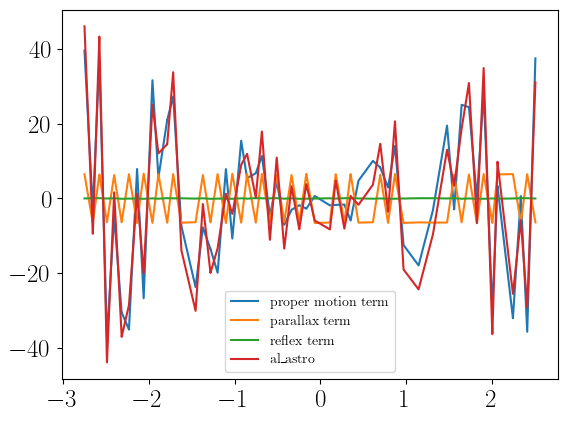

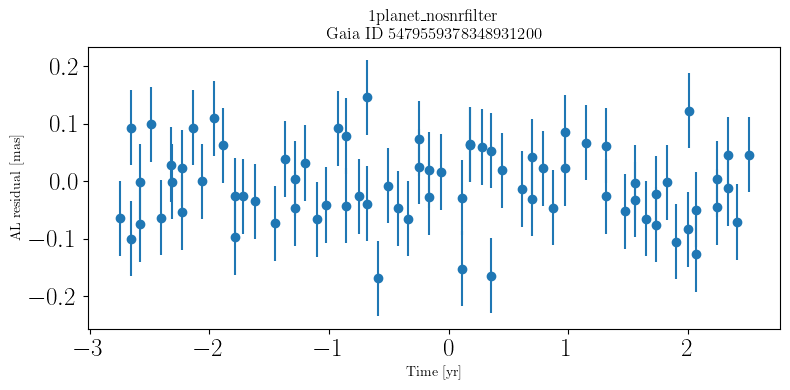

Saved figure: outputs/figures/test_astrometry/residuals_1planet_nosnrfilter_5479559378348931200.pdf


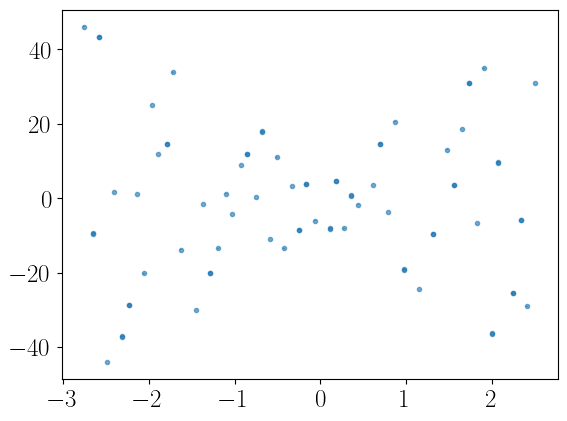

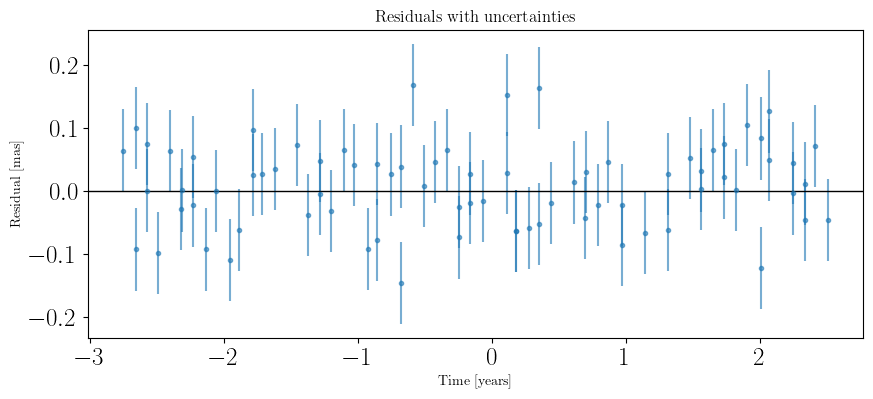


Running test simulation for 1planet_snrfilter
Gaia source ID: 5479559378348931200
Number of planets: 1
Saved CSV: outputs/data/test_astrometry/gaia_dr4_sim_1planet_snrfilter_5479559378348931200.csv


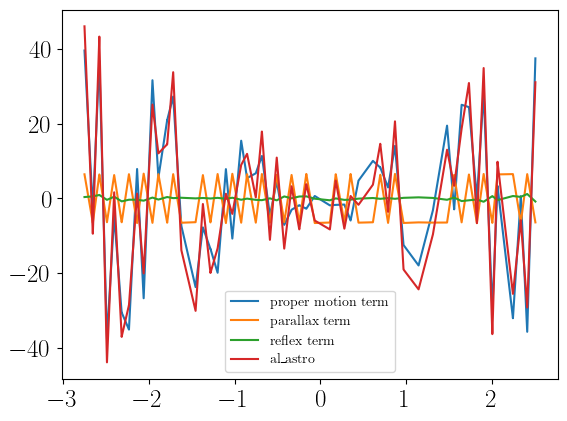

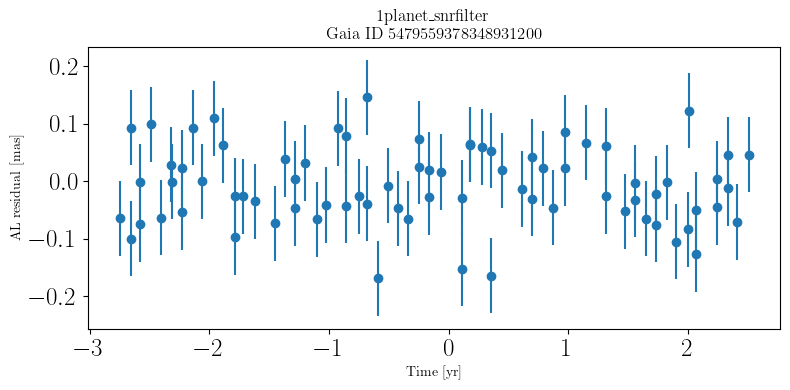

Saved figure: outputs/figures/test_astrometry/residuals_1planet_snrfilter_5479559378348931200.pdf


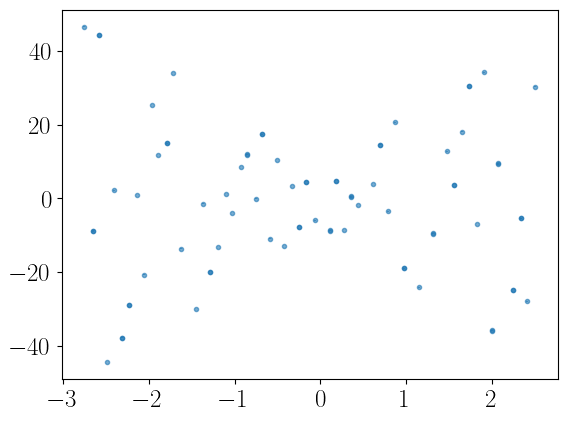

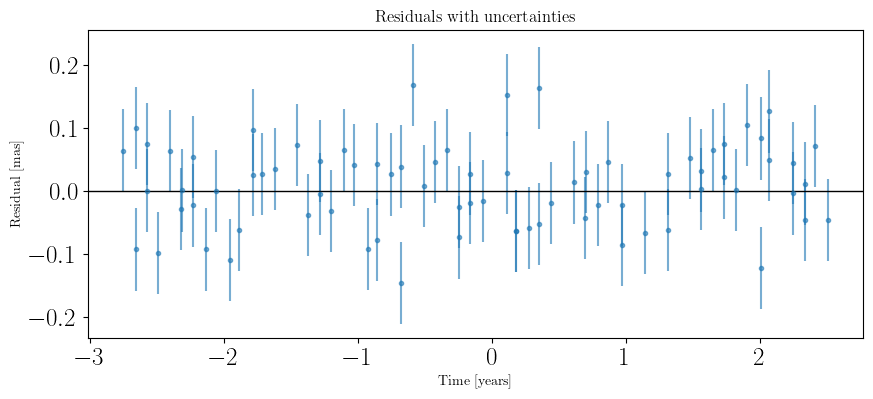


Running test simulation for 2planet_nosnrfilter
Gaia source ID: 5479559378348931200
Number of planets: 2
Saved CSV: outputs/data/test_astrometry/gaia_dr4_sim_2planet_nosnrfilter_5479559378348931200.csv


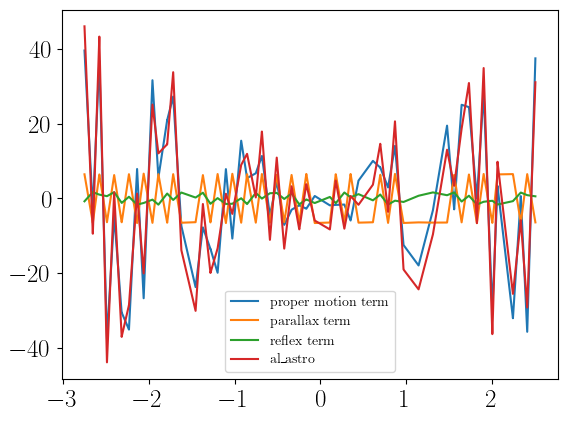

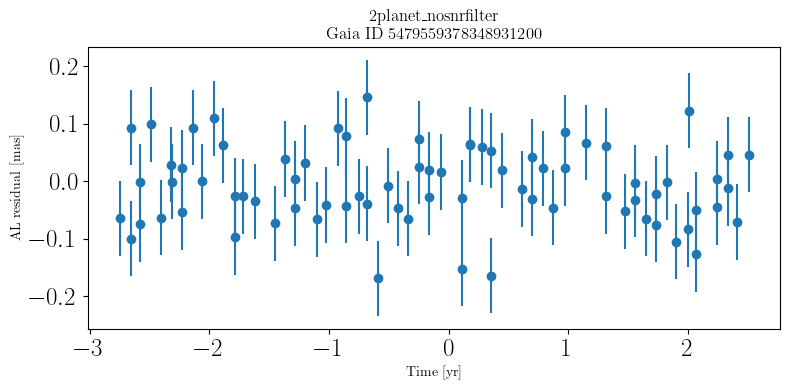

Saved figure: outputs/figures/test_astrometry/residuals_2planet_nosnrfilter_5479559378348931200.pdf


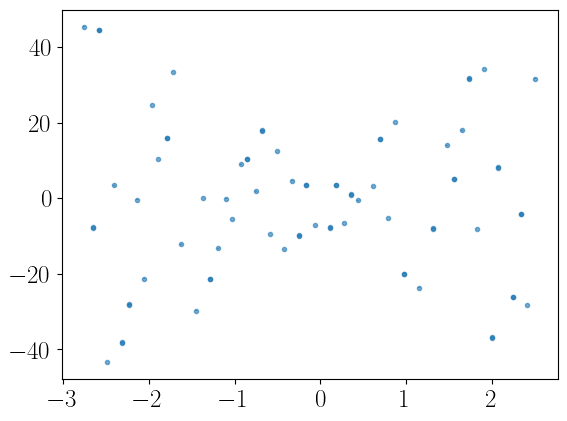

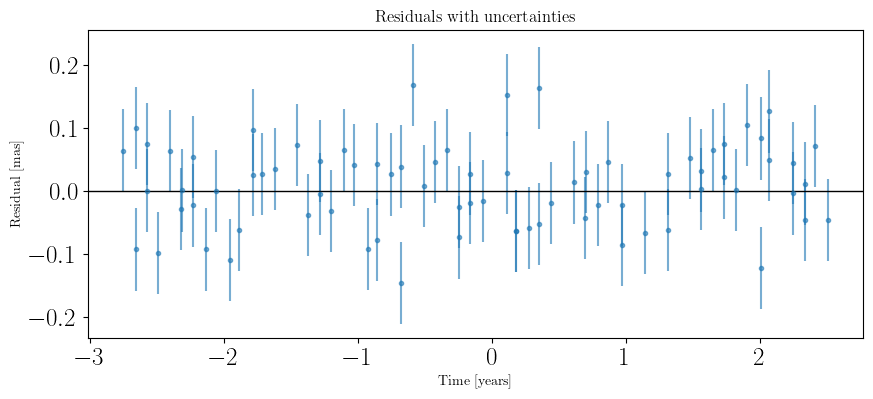


Running test simulation for 2planet_snrfilter
Gaia source ID: 5479559378348931200
Number of planets: 2
Saved CSV: outputs/data/test_astrometry/gaia_dr4_sim_2planet_snrfilter_5479559378348931200.csv


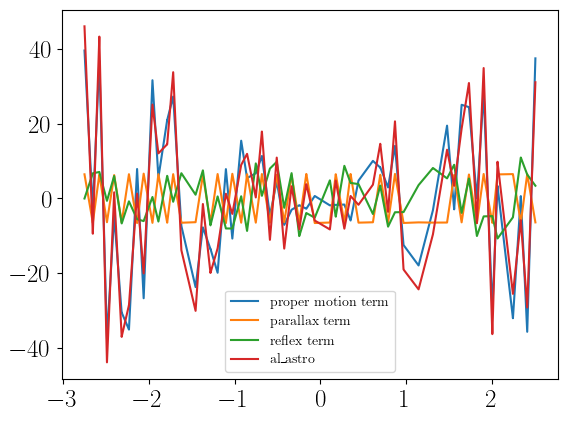

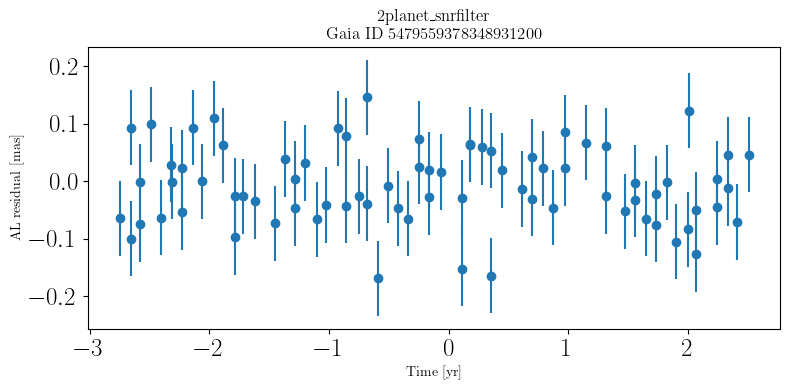

Saved figure: outputs/figures/test_astrometry/residuals_2planet_snrfilter_5479559378348931200.pdf


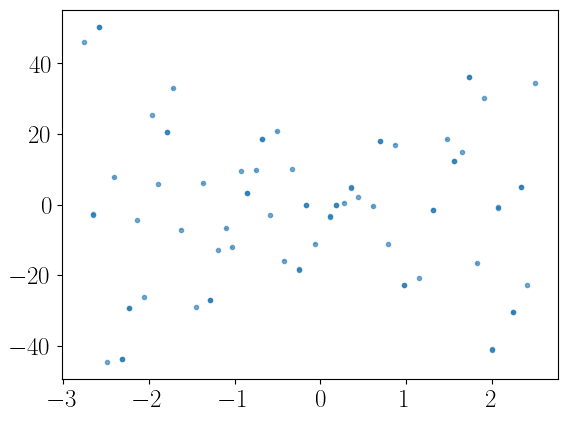

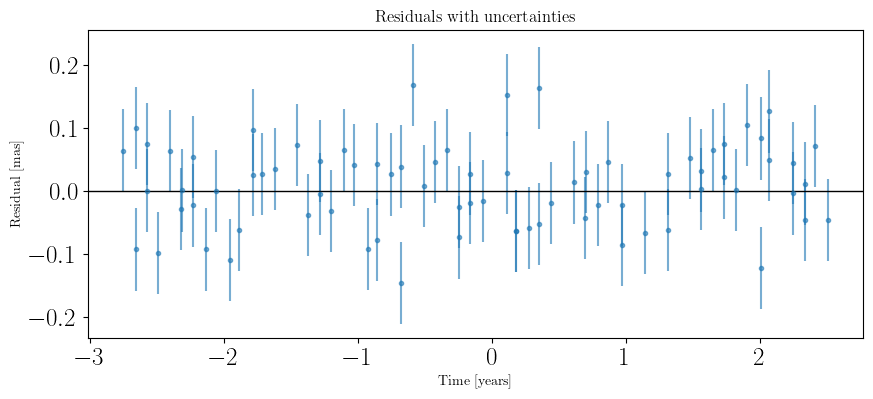

In [18]:
import os
import matplotlib.pyplot as plt


# --------------------------------------------------
# Single-system test for each population
# --------------------------------------------------

sample_scanlaw_dr4_df = sample_scanlaw_dr4_df.copy()
sample_sources_w_mass_radius = sample_sources_w_mass_radius.copy()

sample_scanlaw_dr4_df["gaia_source_id"] = (
    sample_scanlaw_dr4_df["gaia_source_id"]
    .astype("Int64")
    .astype(str)
)

sample_sources_w_mass_radius["gaia_source_id"] = (
    sample_sources_w_mass_radius["gaia_source_id"]
    .astype("Int64")
    .astype(str)
)


test_populations = {
    "1planet_nosnrfilter": systems1_planet_nosnrfilter,
    "1planet_snrfilter": systems1_planet_snrfilter,
    "2planet_nosnrfilter": systems2_planet_nosnrfilter,
    "2planet_snrfilter": systems2_planet_snrfilter,
}

os.makedirs("outputs/data/test_astrometry/", exist_ok=True)
os.makedirs("outputs/figures/test_astrometry/", exist_ok=True)

test_results = {}

for pop_name, systems in test_populations.items():

    # Take the first system in this population
    system = systems[0]

    gaia_source_id = system["gaia_source_id"]
    planets = system["planets"]

    print("\n" + "=" * 70)
    print(f"Running test simulation for {pop_name}")
    print(f"Gaia source ID: {gaia_source_id}")
    print(f"Number of planets: {len(planets)}")
    print("=" * 70)

    output_df, result, source_row, scan_rows = prepare_and_simulate_gaia_astrometry(
        gaia_source_id=gaia_source_id,
        sample_scanlaw_dr4_df=sample_scanlaw_dr4_df,
        sample_sources_df=sample_sources_w_mass_radius,
        planets=planets,
    )

    # Store outputs in memory
    test_results[pop_name] = {
        "gaia_source_id": gaia_source_id,
        "planets": planets,
        "output_df": output_df,
        "result": result,
        "source_row": source_row,
        "scan_rows": scan_rows,
    }

    # Save simulated Gaia-like epoch astrometry
    csv_path = f"outputs/data/test_astrometry/gaia_dr4_sim_{pop_name}_{gaia_source_id}.csv"
    output_df.to_csv(csv_path, index=False)

    print(f"Saved CSV: {csv_path}")

    # Quick residual plot
    plt.figure(figsize=(8, 4))
    plt.errorbar(
        result["t"],
        result["al_true"] - result["al_obs"],
        marker="o",
        ls="",
        yerr=result["sigma_UEVA"],
    )
    plt.xlabel("Time [yr]")
    plt.ylabel("AL residual [mas]")
    plt.title(f"{pop_name}\nGaia ID {gaia_source_id}")
    plt.tight_layout()

    fig_path = f"outputs/figures/test_astrometry/residuals_{pop_name}_{gaia_source_id}.pdf"
    plt.savefig(fig_path)
    plt.show()

    print(f"Saved figure: {fig_path}")

    # Your existing diagnostic plot
    plot_residuals_with_errors(result)

In [17]:
planets1 = [
    {
        "a": .06,
        "e": 0.05,
        "i": np.deg2rad(10.0),
        "Omega": np.deg2rad(20.0),
        "omega": np.deg2rad(70.0),
        "M0": np.deg2rad(10.0),
        "Mp_sun": 8e-2,
    }
]

gaia_source_id = 1661568850770761600
output_df1, result1, source_row1, scan_rows1 = prepare_and_simulate_gaia_astrometry(
    gaia_source_id=gaia_source_id,
    sample_scanlaw_dr4_df=sample_scanlaw_dr4_df,
    sample_sources_df=sample_sources_w_mass_radius,
    planets=planets1
)

plt.figure()
plt.errorbar(result1['t'], result1['al_astro']-result1['al_obs'], marker='o', ls='', yerr=result1['sigma_UEVA'])
plt.show()

plot_residuals_with_errors(result1)
output_df1.to_csv('gaia_dr4_sim_HJ_take5.csv')

ValueError: No source found in sample_sources_df for gaia_source_id=1661568850770761600